##  Phase 3 – Application – Dataset MPG

In [181]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scipy.stats import binomtest
from scipy.stats import chisquare
from scipy.stats import ttest_1samp
from scipy.stats import chi2_contingency
from scipy.stats import pearsonr

In [182]:
df = sns.load_dataset('mpg')
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


1. ## the descrite variables in thise dataset is :
cylinders,
origin,
name,


In [183]:
descrite1 = df['cylinders'].describe()
descrite2 = df['origin'].describe()
descrite3 = df['mpg'].describe()

2. # analayse the variable mpg
What is the average? What does it actually represent? (Be specific.)

 Draw two relevant graphs for this variable.

In [184]:
df['mpg'].median()

np.float64(23.0)

In [185]:
df['mpg'].mean()

np.float64(23.514572864321607)

Text(0.5, 1.0, 'MPG Box Plot')

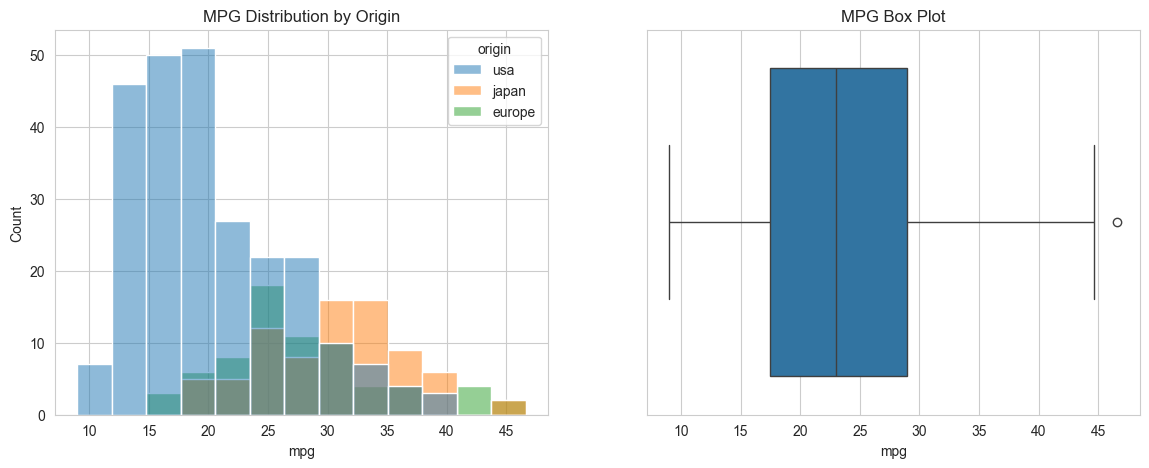

In [186]:
figure, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(x=df['mpg'], hue=df['origin'], ax=axes[0])
axes[0].set_title('MPG Distribution by Origin')

sns.boxplot(x=df['mpg'], ax=axes[1])
axes[1].set_title('MPG Box Plot')

## Analayse the variable cylinders

In [187]:
df['cylinders'].value_counts()
df['cylinders'].describe()


count    398.000000
mean       5.454774
std        1.701004
min        3.000000
25%        4.000000
50%        4.000000
75%        8.000000
max        8.000000
Name: cylinders, dtype: float64

## Analyze the varible the origin 

In [188]:
df['origin'].count()
df['origin'].value_counts()

origin
usa       249
japan      79
europe     70
Name: count, dtype: int64

Text(0.5, 1.0, 'Origin Count')

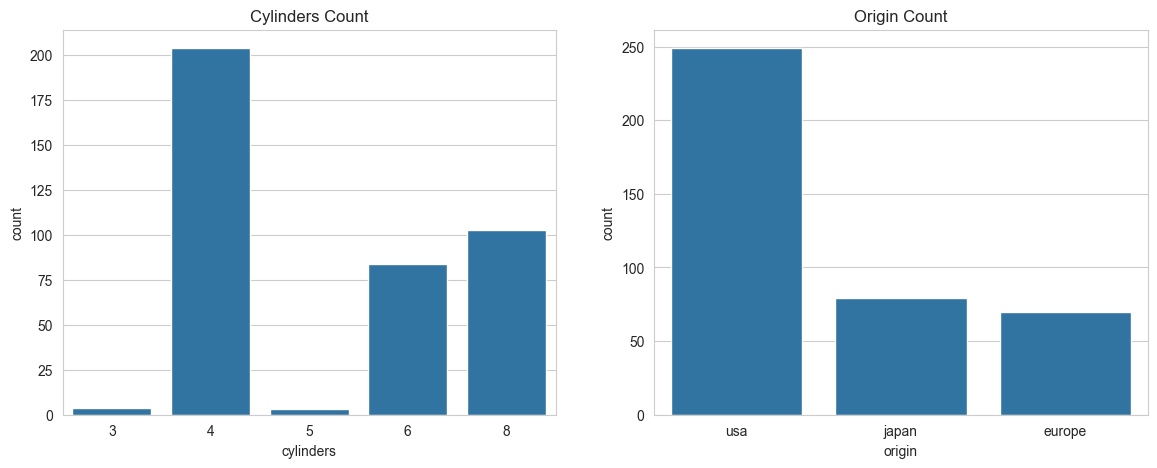

In [189]:
figure, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data = df, x = 'cylinders',ax= axes[0],)
axes[0].set_title('Cylinders Count')

sns.countplot(data = df, x = 'origin',ax=axes[1], order=df['origin'])
axes[1].set_title('Origin Count')


## Observez l'évolution de la consommation des voitures (mpg) par rapport au nombre de chevaux (horsepower)

What do we seem to see?
Add the model year variable. What do we see?

<Axes: xlabel='cylinders', ylabel='mpg'>

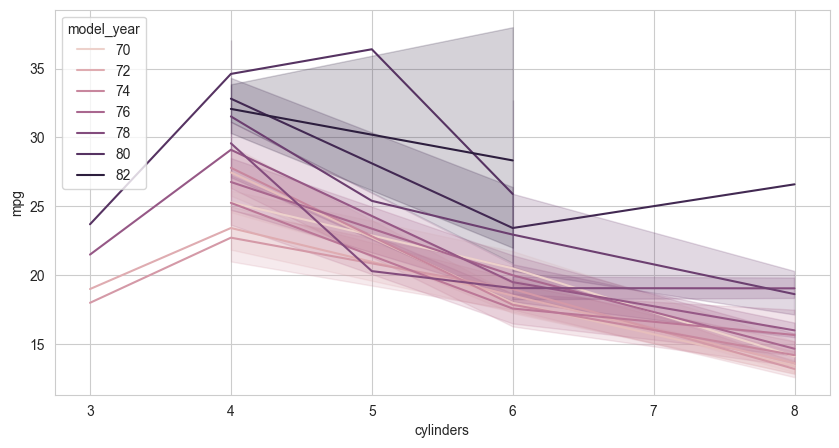

In [190]:
figure, axes = plt.subplots(1,figsize=(10, 5))
sns.lineplot(x=df['cylinders'], y=df['mpg'], hue = df['model_year'])

## Observez l'évolution du poids moyen des voitures américaines de l'année 70 jusqu'à l'année 82.

In [191]:
evolutiion = df[df['model_year'].between(70,82)]
evolutiion

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


In [192]:
pd.crosstab(df['cylinders'],  df['model_year'])

model_year,70,71,72,73,74,75,76,77,78,79,80,81,82
cylinders,,,,,,,,,,,,,
3,0,0,1,1,0,0,0,1,0,0,1,0,0
4,7,13,14,11,15,12,15,14,17,12,25,21,28
5,0,0,0,0,0,0,0,0,1,1,1,0,0
6,4,8,0,8,7,12,10,5,12,6,2,7,3
8,18,7,13,20,5,6,9,8,6,10,0,1,0


Text(0.5, 1.0, 'Cylinders Distribution by Model Year')

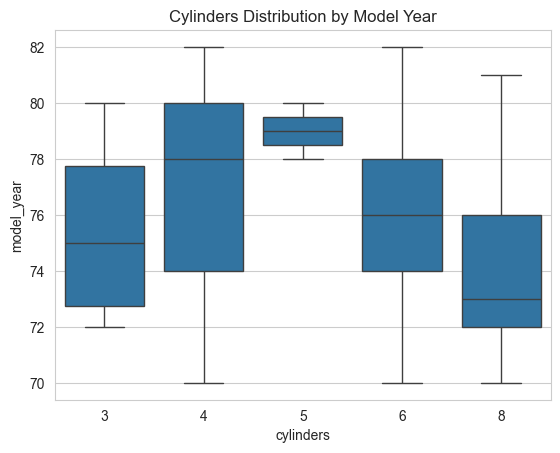

In [193]:
sns.set_style("whitegrid")

sns.boxplot(x='cylinders', y='model_year', data = df)
plt.title('Cylinders Distribution by Model Year')

<Axes: xlabel='model_year'>

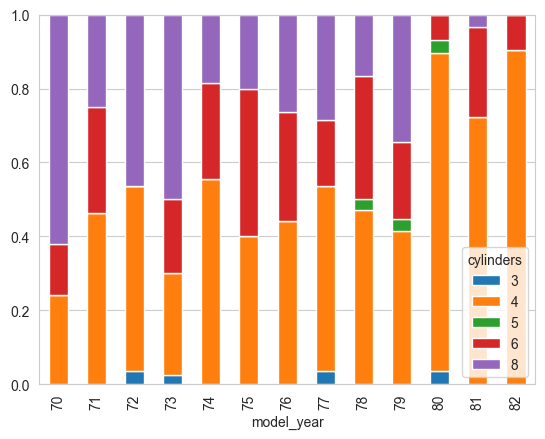

In [194]:
pd.crosstab(df['model_year'], df['cylinders'], normalize="index").plot(kind="bar", stacked=True)

## Analysez la relation entre le nombre de cylindres et l'origine.

In [195]:
pd.crosstab(df['cylinders'], df['origin'])

origin,europe,japan,usa
cylinders,,,
3,0,4,0
4,63,69,72
5,3,0,0
6,4,6,74
8,0,0,103


## Quelle est l'accélération moyenne des voitures des différents pays 

<Axes: xlabel='acceleration', ylabel='origin'>

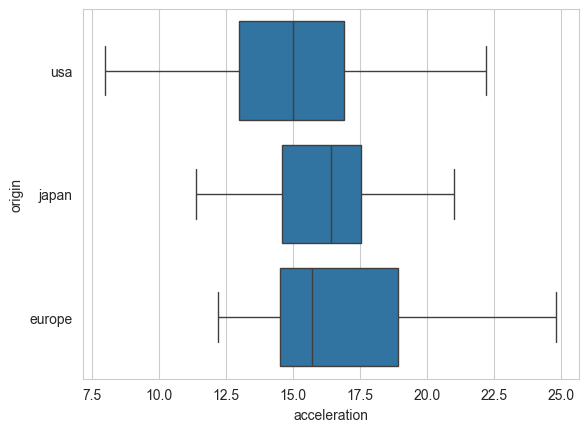

In [196]:
sns.boxplot( data = df, x = 'acceleration', y = 'origin')

## Quelle est-elle pour les modèles de l'année 80

<Axes: xlabel='model_year', ylabel='acceleration'>

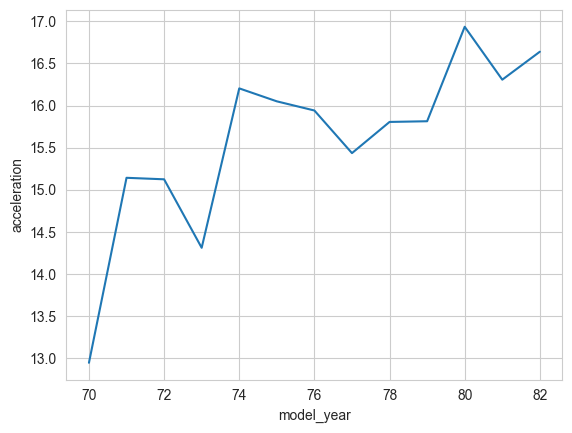

In [210]:
sns.lineplot(
    data=df.groupby('model_year')['acceleration'].mean().reset_index(),
    x='model_year',
    y='acceleration'
)

## Au final Il semblerait qu'une tendance se dégage à travers le temps
List all the phenomena that seem to occur (decrease? increase?) for the different variables and groups
## list of all the phenomena in this data:

## Key Observed Phenomena


mpg (fuel efficiency) → 📈 increases over time

👉 Cars become more fuel-efficient

weight → 📉 decreases over time

👉 Cars become lighter

horsepower → 📉 decreases over time

👉 Engines become less powerful (more efficient focus)

displacement → 📉 decreases

👉 Smaller engines over time

acceleration → 📈 slight increase

👉 Cars take a bit longer to accelerate (efficiency trade-off)

## 2. Relationships Between Variables

mpg vs weight → 📉 strong negative relationship

👉 Heavier cars → lower fuel efficiency

mpg vs horsepower → 📉 negative relationship

👉 More powerful cars → consume more fuel

mpg vs displacement → 📉 negative relationship

👉 Bigger engines → worse mpg

weight vs horsepower → 📈 positive relationship

👉 Heavier cars tend to have more powerful engines

## Summary (Big Picture)
Cars evolved toward efficiency:

lighter

smaller engines

better fuel economy

Trade-off:

slightly slower acceleration

less horsepower